In [3]:
def train(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


# Resnet 18


### Linear Probing


In [4]:
from torchvision.datasets import Food101
from torchvision import transforms
import torch
from torch.utils.data import DataLoader
from torchvision.models import ResNet18_Weights
import torchvision.models as models

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)


weights = ResNet18_Weights.DEFAULT


transform = weights.transforms()

# Datasets
train_dataset = Food101(
    root="data",
    split="train",
    download=True,
    transform=transform
)

val_dataset = Food101(
    root="data",
    split="test",
    download=True,
    transform=transform
)

# Dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

# Just do linear probing to establish baseline
# Freeze all layers except the final fully connected layer
for param in model.parameters():
    param.requires_grad = False
# Replace the final fully connected layer to match the number of classes in Food101
num_classes = 101

model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)
    
criterion = torch.nn.CrossEntropyLoss()
trainable_params = list(filter(lambda p: p.requires_grad, model.parameters()))
print(f"Number of trainable parameters: {sum(p.numel() for p in trainable_params)}")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
train_accs = []
val_accs = []

import os

if os.path.exists("checkpoint_resnet18_linear_probe.pt"):
    print("Loading checkpoint...")
    checkpoint = torch.load("checkpoint_resnet18_linear_probe.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    curr_epoch = 0
    best_val_acc = 0.0
    print("No checkpoint found, starting training from scratch")

Number of trainable parameters: 51813
Loading checkpoint...
Resuming from epoch 9 with best validation accuracy 0.5851


In [5]:
# while curr_epoch < 8:
#     train_loss, train_acc = train(model, train_dataloader, criterion, optimizer, device)
#     val_loss, val_acc = validate(model, val_dataloader, criterion, device)
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
    
#     train_accs.append(train_acc)
#     val_accs.append(val_acc)
    
    
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save({
#             "epoch": curr_epoch,
#             "model_state": model.state_dict(),
#             "optimizer_state": optimizer.state_dict(),
#             "best_val_acc": best_val_acc
#         }, "checkpoint_resnet18_linear_probe.pt")

#     print(f"Epoch {curr_epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
#     curr_epoch += 1

# print("Training complete!")
# print("Saving final model checkpoint")
# torch.save({
#     "epoch": curr_epoch,
#     "model_state": model.state_dict(),
#     "optimizer_state": optimizer.state_dict(),
#     "best_val_acc": best_val_acc,
#     "train_accs": train_accs,
#     "train_losses": train_losses,
#     "val_accs": val_accs,
#     "val_losses": val_losses
# }, "final_checkpoint_resnet18_linear_probe.pt")

In [6]:
if os.path.exists("final_checkpoint_efficientnet_linear_probe.pt"):
    print("Loading final checkpoint for plotting...")
    checkpoint = torch.load("final_checkpoint_efficientnet_linear_probe.pt", map_location=device)
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])

Loading final checkpoint for plotting...


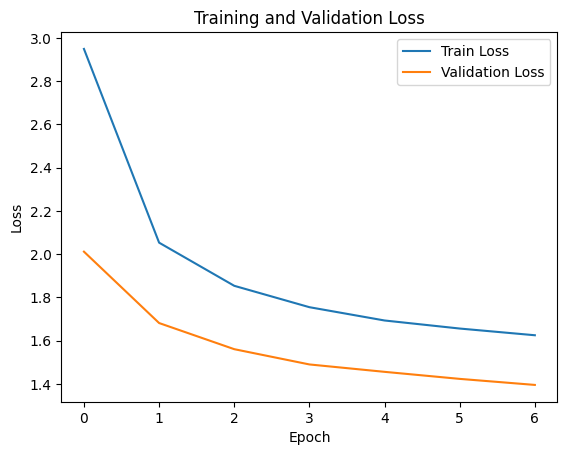

In [7]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

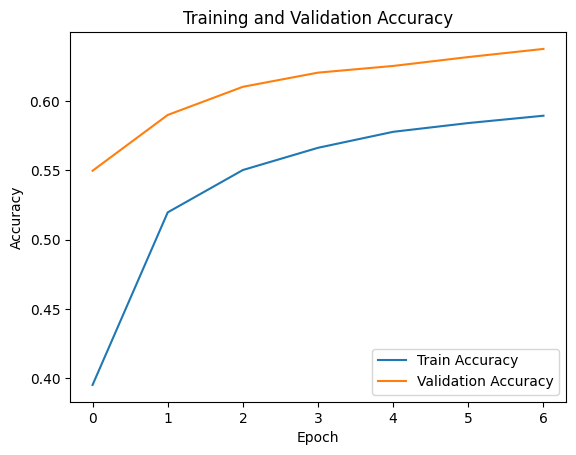

In [8]:
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()  

### Batchnorm tuning


In [9]:
import torch
import os


model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

weights = ResNet18_Weights.DEFAULT


transform = weights.transforms()

# Datasets
train_dataset = Food101(
    root="data",
    split="train",
    download=True,
    transform=transform
)

val_dataset = Food101(
    root="data",
    split="test",
    download=True,
    transform=transform
)

# Dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)



# 1. Freeze everything
for param in model.parameters():
    param.requires_grad = False

# 2. Unfreeze classifier (final linear layer)
# Replace the final fully connected layer to match the number of classes in Food101
num_classes = 101

model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

for param in model.fc.parameters():
    param.requires_grad = True


# 3. Batch norm tuning. Tuning Beta and Gamma parameters
for m in model.modules():
    if isinstance(m, torch.nn.BatchNorm2d):
        for param in m.parameters():
            param.requires_grad = True


if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)







    
    
criterion = torch.nn.CrossEntropyLoss()
training_params = list(filter(lambda p: p.requires_grad, model.parameters()))

print("number of trainable parameters:", sum(p.numel() for p in training_params))

optimizer = torch.optim.Adam(training_params, lr=1e-3)

train_losses = []
val_losses = []
train_accs = []
val_accs = []


if os.path.exists("checkpoint_resnet18_batch_norm.pt"):
    print("Loading checkpoint...")
    checkpoint = torch.load("checkpoint_resnet18_batch_norm.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    curr_epoch = 0
    best_val_acc = 0.0
    print("No checkpoint found, starting training from scratch")
    



number of trainable parameters: 61413
Loading checkpoint...
Resuming from epoch 6 with best validation accuracy 0.6896


In [10]:
# while curr_epoch < 8:
#     train_loss, train_acc = train(model, train_dataloader, criterion, optimizer, device)
#     val_loss, val_acc = validate(model, val_dataloader, criterion, device)
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
    
#     train_accs.append(train_acc)
#     val_accs.append(val_acc)
    
    
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save({
#             "epoch": curr_epoch,
#             "model_state": model.state_dict(),
#             "optimizer_state": optimizer.state_dict(),
#             "best_val_acc": best_val_acc
#         }, "checkpoint_resnet18_batch_norm.pt")

#     print(f"Epoch {curr_epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
#     curr_epoch += 1

# print("Training complete!")
# print("Saving final model checkpoint")
# torch.save({
#     "epoch": curr_epoch,
#     "model_state": model.state_dict(),
#     "optimizer_state": optimizer.state_dict(),
#     "best_val_acc": best_val_acc,
#     "train_accs": train_accs,
#     "train_losses": train_losses,
#     "val_accs": val_accs,
#     "val_losses": val_losses
# }, "final_checkpoint_resnet18_batch_norm.pt")

In [11]:
if os.path.exists("final_checkpoint_resnet18_batch_norm.pt"):
    print("Loading final checkpoint...")
    checkpoint = torch.load("final_checkpoint_resnet18_batch_norm.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    curr_epoch = 0
    best_val_acc = 0.0
    print("No checkpoint found, starting training from scratch")

Loading final checkpoint...
Resuming from epoch 9 with best validation accuracy 0.6896


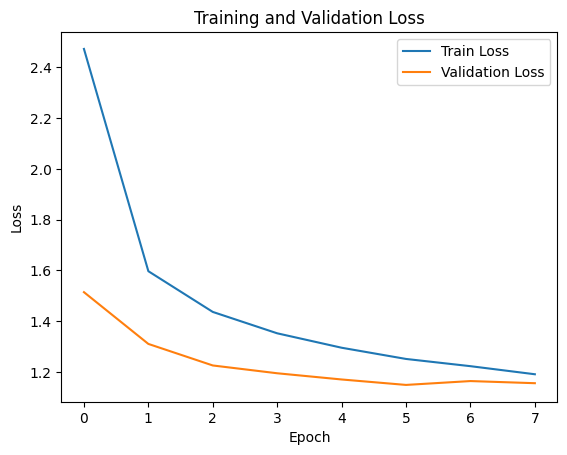

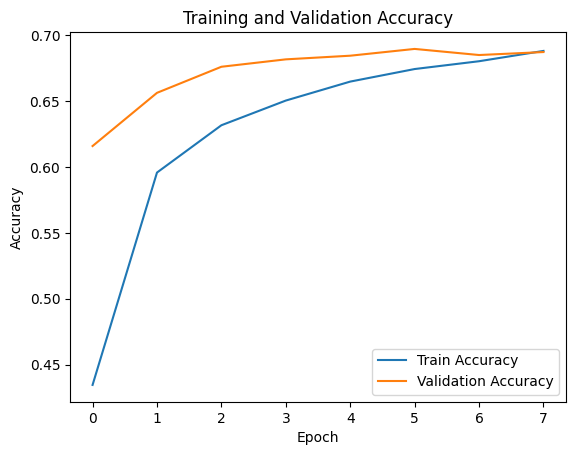

In [12]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()  

### Task Specific Adapter

In [30]:
import torch.nn as nn

class CNNAdapter(nn.Module):
    def __init__(self, channels, reduction_factor=8):
        super().__init__()
        bottleneck = channels // reduction_factor
        self.adapter = nn.Sequential(
            nn.Conv2d(channels, bottleneck, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(bottleneck, channels, kernel_size=1)
        )

    def forward(self, x):
        return x + self.adapter(x) 
    

class ResNetWithAdapters(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

        self.adapters = nn.ModuleDict({
            "layer1": CNNAdapter(64),
            "layer2": CNNAdapter(128),
            "layer3": CNNAdapter(256),
            "layer4": CNNAdapter(512),
        })

    def forward(self, x):
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)

        x = self.model.layer1(x)
        x = self.adapters["layer1"](x)

        x = self.model.layer2(x)
        x = self.adapters["layer2"](x)

        x = self.model.layer3(x)
        x = self.adapters["layer3"](x)

        x = self.model.layer4(x)
        x = self.adapters["layer4"](x)

        x = self.model.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.model.fc(x)

        return x

model = ResNetWithAdapters(models.resnet18(weights=models.ResNet18_Weights.DEFAULT))


# Freeze backbone
for param in model.model.parameters():
    param.requires_grad = False

# Replace classifier
model.model.fc = torch.nn.Linear(model.model.fc.in_features, 101)

# Unfreeze adapters
for param in model.adapters.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.model.fc.parameters():
    param.requires_grad = True

print(model.adapters)




    
criterion = torch.nn.CrossEntropyLoss()
training_params = list(filter(lambda p: p.requires_grad, model.parameters()))

print("number of trainable parameters:", sum(p.numel() for p in training_params))

optimizer = torch.optim.Adam(training_params, lr=1e-3)





ModuleDict(
  (layer1): CNNAdapter(
    (adapter): Sequential(
      (0): Conv2d(64, 8, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(8, 64, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (layer2): CNNAdapter(
    (adapter): Sequential(
      (0): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(16, 128, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (layer3): CNNAdapter(
    (adapter): Sequential(
      (0): Conv2d(256, 32, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 256, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (layer4): CNNAdapter(
    (adapter): Sequential(
      (0): Conv2d(512, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 512, kernel_size=(1, 1), stride=(1, 1))
    )
  )
)
number of trainable parameters: 139933


In [31]:
import torch
import os
from torchvision.models import ResNet18_Weights




weights = ResNet18_Weights.DEFAULT


transform = weights.transforms()

# Datasets
train_dataset = Food101(
    root="data",
    split="train",
    download=True,
    transform=transform
)

val_dataset = Food101(
    root="data",
    split="test",
    download=True,
    transform=transform
)

# Dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)



if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)




train_losses = []
val_losses = []
train_accs = []
val_accs = []


if os.path.exists("checkpoint_resnet18_task_specific_adapter.pt"):
    print("Loading checkpoint...")
    checkpoint = torch.load("checkpoint_resnet18_task_specific_adapter.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    curr_epoch = 0
    best_val_acc = 0.0
    print("No checkpoint found, starting training from scratch")
    



Loading checkpoint...
Resuming from epoch 8 with best validation accuracy 0.6790


In [15]:
# while curr_epoch < 8:
#     train_loss, train_acc = train(model, train_dataloader, criterion, optimizer, device)
#     val_loss, val_acc = validate(model, val_dataloader, criterion, device)
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     train_accs.append(train_acc)
#     val_accs.append(val_acc)
    
    
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save({
#             "epoch": curr_epoch,
#             "model_state": model.state_dict(),
#             "optimizer_state": optimizer.state_dict(),
#             "best_val_acc": best_val_acc
#         }, "checkpoint_resnet18_task_specific_adapter.pt")

#     print(f"Epoch {curr_epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
#     curr_epoch += 1

# print("Training complete!")
# print("Saving final model checkpoint")
# torch.save({
#     "epoch": curr_epoch,
#     "model_state": model.state_dict(),
#     "optimizer_state": optimizer.state_dict(),
#     "best_val_acc": best_val_acc,
#     "val_accs": val_accs,
#     "val_losses": val_losses,
#     "train_accs": train_accs,
#     "train_losses": train_losses
# }, "final_checkpoint_resnet18_task_specific_adapter.pt")

Loading final checkpoint for plotting...


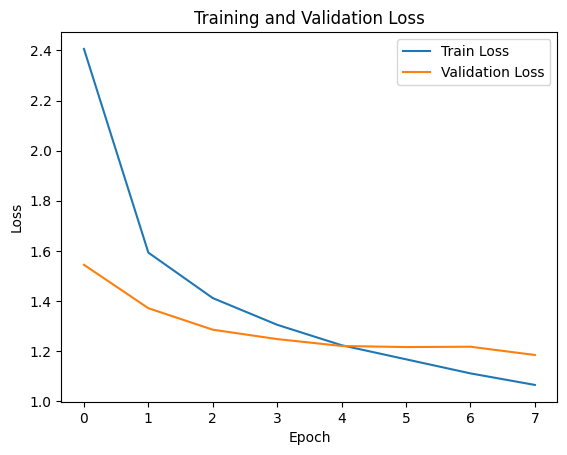

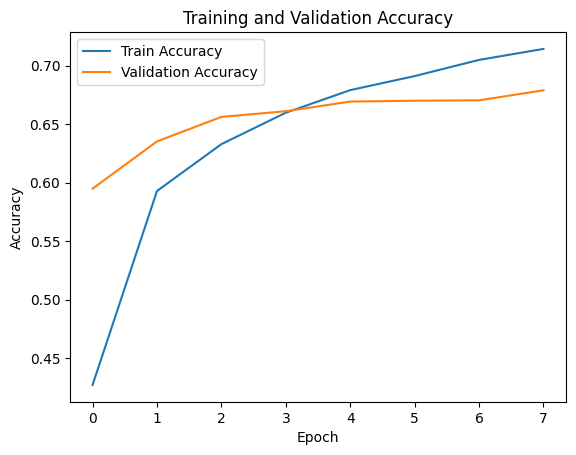

In [32]:
if os.path.exists("final_checkpoint_resnet18_task_specific_adapter.pt"):
    print("Loading final checkpoint for plotting...")
    checkpoint = torch.load("final_checkpoint_resnet18_task_specific_adapter.pt", map_location=device)
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()  


# Efficient Net 2

### Linear Probing


In [25]:
from torchvision.datasets import Food101
from torchvision import transforms
import torch
from torch.utils.data import DataLoader
from torchvision.models import EfficientNet_V2_S_Weights
import torchvision.models as models
import torch



model = models.efficientnet_v2_s(
    weights=models.EfficientNet_V2_S_Weights.DEFAULT
)



weights = EfficientNet_V2_S_Weights.DEFAULT


transform = weights.transforms()

# Datasets
train_dataset = Food101(
    root="data",
    split="train",
    download=True,
    transform=transform
)

val_dataset = Food101(
    root="data",
    split="test",
    download=True,
    transform=transform
)

# Dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

# Just do linear probing to establish baseline
# Freeze all layers except the final fully connected layer
for param in model.parameters():
    param.requires_grad = False
# Replace the final fully connected layer to match the number of classes in Food101
num_classes = 101

in_features = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(in_features, num_classes)




if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0
curr_epoch = 0


import os

if os.path.exists("checkpoint_efficientnet_linear_probe.pt"):
    print("Loading checkpoint...")
    checkpoint = torch.load("checkpoint_efficientnet_linear_probe.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    print("No checkpoint found, starting training from scratch")


    


Loading checkpoint...
Resuming from epoch 7 with best validation accuracy 0.6375


In [18]:
# while curr_epoch < 8:
#     train_loss, train_acc = train(model, train_dataloader, criterion, optimizer, device)
#     val_loss, val_acc = validate(model, val_dataloader, criterion, device)
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     train_accs.append(train_acc)
#     val_accs.append(val_acc)
    
    
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save({
#             "epoch": curr_epoch,
#             "model_state": model.state_dict(),
#             "optimizer_state": optimizer.state_dict(),
#             "best_val_acc": best_val_acc
#         }, "checkpoint_efficientnet_linear_probe.pt")

#     print(f"Epoch {curr_epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
#     curr_epoch += 1

# print("Training complete!")
# print("Saving final model checkpoint")
# torch.save({
#     "epoch": curr_epoch,
#     "model_state": model.state_dict(),
#     "optimizer_state": optimizer.state_dict(),
#     "best_val_acc": best_val_acc,
#     "val_accs": val_accs,
#     "val_losses": val_losses,
#     "train_accs": train_accs,
#     "train_losses": train_losses
# }, "final_checkpoint_efficientnet_linear_probe.pt")

In [26]:
if os.path.exists("final_checkpoint_efficientnet_linear_probe.pt"):
    print("Loading final checkpoint...")
    checkpoint = torch.load("final_checkpoint_efficientnet_linear_probe.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    curr_epoch = 0
    best_val_acc = 0.0
    print("No checkpoint found, starting training from scratch")

Loading final checkpoint...
Resuming from epoch 8 with best validation accuracy 0.6375


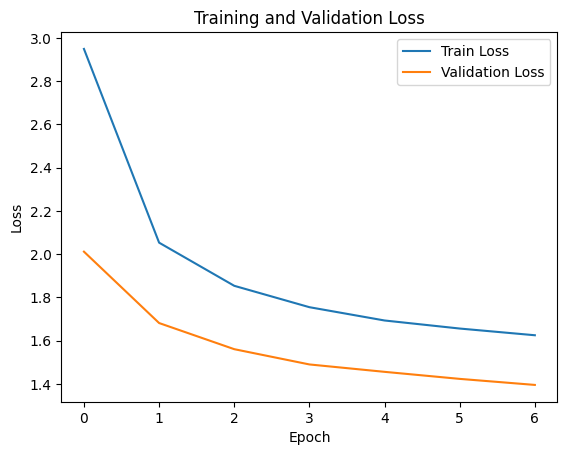

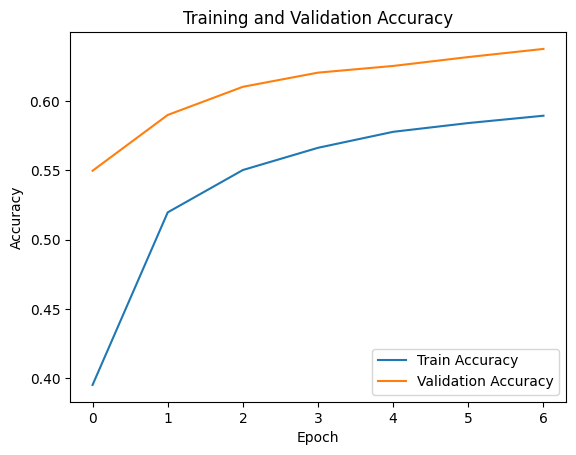

In [27]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()  

### Batchnorm

In [21]:
from torchvision.datasets import Food101
from torchvision import transforms
import torch
from torch.utils.data import DataLoader
from torchvision.models import EfficientNet_V2_S_Weights
import torchvision.models as models
import torch



model = models.efficientnet_v2_s(
    weights=models.EfficientNet_V2_S_Weights.DEFAULT
)



weights = EfficientNet_V2_S_Weights.DEFAULT


transform = weights.transforms()

# Datasets
train_dataset = Food101(
    root="data",
    split="train",
    download=True,
    transform=transform
)

val_dataset = Food101(
    root="data",
    split="test",
    download=True,
    transform=transform
)

# Dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

# Just do linear probing to establish baseline
# Freeze all layers except the final fully connected layer
for param in model.parameters():
    param.requires_grad = False
# Replace the final fully connected layer to match the number of classes in Food101
num_classes = 101

in_features = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(in_features, num_classes)

# Batch norm tuning. Unfreeze Beta and Gamma parameters
for m in model.modules():
    if isinstance(m, torch.nn.BatchNorm2d):
        for param in m.parameters():
            param.requires_grad = True




if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)

criterion = torch.nn.CrossEntropyLoss()
training_params = list(filter(lambda p: p.requires_grad, model.parameters()))
optimizer = torch.optim.Adam(training_params, lr=0.001)
print("number of trainable parameters:", sum(p.numel() for p in training_params))

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0
curr_epoch = 0


import os

if os.path.exists("checkpoint_efficientnet_batch_norm.pt"):
    print("Loading checkpoint...")
    checkpoint = torch.load("checkpoint_efficientnet_batch_norm.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    print("No checkpoint found, starting training from scratch")


    


number of trainable parameters: 283253
No checkpoint found, starting training from scratch


In [22]:
while curr_epoch < 8:
    train_loss, train_acc = train(model, train_dataloader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_dataloader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": curr_epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_acc": best_val_acc
        }, "checkpoint_efficientnet_batch_norm.pt")

    print(f"Epoch {curr_epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
    curr_epoch += 1

print("Training complete!")
print("Saving final model checkpoint")
torch.save({
    "epoch": curr_epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "best_val_acc": best_val_acc,
    "val_accs": val_accs,
    "val_losses": val_losses,
    "train_accs": train_accs,
    "train_losses": train_losses
}, "final_checkpoint_efficientnet_batch_norm.pt")

/opt/homebrew/Caskroom/miniforge/base/envs/cv_env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [ ]:
if os.path.exists("final_checkpoint_efficientnet_batch_norm.pt"):
    print("Loading final checkpoint...")
    checkpoint = torch.load("final_checkpoint_efficientnet_batch_norm.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    curr_epoch = 0
    best_val_acc = 0.0
    print("No checkpoint found, starting training from scratch")


import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()  

### Task specific adapters


In [ ]:
import torch.nn as nn

class CNNAdapter(nn.Module):
    def __init__(self, channels, reduction_factor=8):
        super().__init__()
        bottleneck = channels // reduction_factor
        self.adapter = nn.Sequential(
            nn.Conv2d(channels, bottleneck, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(bottleneck, channels, kernel_size=1)
        )

    def forward(self, x):
        return x + self.adapter(x) 
    


class EfficientNetWithAdapters(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

        # pick certain stages to add adapters to. 
        self.adapter_indices = [3, 5, 6]  

        self.adapters = nn.ModuleDict({
            str(i): CNNAdapter(self._get_channels(i))
            for i in self.adapter_indices
        })

    def _get_channels(self, idx):
        # get output channels of that stage
        return self.model.features[idx][-1].out_channels

    def forward(self, x):
        for i, layer in enumerate(self.model.features):
            x = layer(x)
            if str(i) in self.adapters:
                x = self.adapters[str(i)](x)

        x = self.model.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.model.classifier(x)
        return x

base_model = models.efficientnet_v2_s(
    weights=models.EfficientNet_V2_S_Weights.DEFAULT
)

model = EfficientNetWithAdapters(base_model)


# Freeze backbone
for param in model.model.parameters():
    param.requires_grad = False

# Replace classifier
in_features = model.model.classifier[1].in_features
model.model.classifier[1] = nn.Linear(in_features, 101)

# Unfreeze adapters
for param in model.adapters.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.model.classifier.parameters():
    param.requires_grad = True

print(model.adapters)




    
criterion = torch.nn.CrossEntropyLoss()
training_params = list(filter(lambda p: p.requires_grad, model.parameters()))

print("number of trainable parameters:", sum(p.numel() for p in training_params))

optimizer = torch.optim.Adam(training_params, lr=1e-3)





ModuleDict(
  (3): CNNAdapter(
    (adapter): Sequential(
      (0): Conv2d(64, 8, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(8, 64, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (5): CNNAdapter(
    (adapter): Sequential(
      (0): Conv2d(160, 20, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(20, 160, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (6): CNNAdapter(
    (adapter): Sequential(
      (0): Conv2d(256, 32, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 256, kernel_size=(1, 1), stride=(1, 1))
    )
  )
)
number of trainable parameters: 153729


In [23]:
from torchvision.datasets import Food101
from torchvision import transforms
import torch
from torch.utils.data import DataLoader
from torchvision.models import EfficientNet_V2_S_Weights
import torchvision.models as models
import torch




weights = EfficientNet_V2_S_Weights.DEFAULT


transform = weights.transforms()

# Datasets
train_dataset = Food101(
    root="data",
    split="train",
    download=True,
    transform=transform
)

val_dataset = Food101(
    root="data",
    split="test",
    download=True,
    transform=transform
)

# Dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)



if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)



train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0
curr_epoch = 0


import os

if os.path.exists("checkpoint_efficientnet_task_specific_adapters.pt"):
    print("Loading checkpoint...")
    checkpoint = torch.load("checkpoint_efficientnet_task_specific_adapters.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    print("No checkpoint found, starting training from scratch")


    


No checkpoint found, starting training from scratch


In [ ]:
while curr_epoch < 8:
    train_loss, train_acc = train(model, train_dataloader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_dataloader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": curr_epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_acc": best_val_acc
        }, "checkpoint_efficientnet_task_specific_adapters.pt")

    print(f"Epoch {curr_epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
    curr_epoch += 1

print("Training complete!")
print("Saving final model checkpoint")
torch.save({
    "epoch": curr_epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "best_val_acc": best_val_acc,
    "val_accs": val_accs,
    "val_losses": val_losses,
    "train_accs": train_accs,
    "train_losses": train_losses
}, "final_checkpoint_efficientnet_task_specific_adapters.pt")

In [ ]:
if os.path.exists("final_checkpoint_efficientnet_task_specific_adapters.pt"):
    print("Loading final checkpoint...")
    checkpoint = torch.load("final_checkpoint_efficientnet_task_specific_adapters.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    curr_epoch = 0
    best_val_acc = 0.0
    print("No checkpoint found, starting training from scratch")


import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()  

# Custom Model

Specific adapter tuned resnet 18 model, with attention layers

In [43]:


import torch
import torch.nn as nn



class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        # x: (B, C, H, W)

        avg = torch.mean(x, dim=1, keepdim=True)      # (B, 1, H, W)
        max, _ = torch.max(x, dim=1, keepdim=True)    # (B, 1, H, W)

        x_cat = torch.cat([avg, max], dim=1)          # (B, 2, H, W)
        mask = torch.sigmoid(self.conv(x_cat))        # (B, 1, H, W)

        return x * mask

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels)
        )

    def forward(self, x):
        b, c, h, w = x.shape

        avg = torch.mean(x, dim=(2, 3))               # (B, C)
        max, _ = torch.max(x.view(b, c, -1), dim=2)   # (B, C)

        attn = self.mlp(avg) + self.mlp(max)
        attn = torch.sigmoid(attn).view(b, c, 1, 1)

        return x * attn

class CBAMAdapter(nn.Module):
    def __init__(self, channels, reduction_factor=8):
        super().__init__()
        
        bottleneck = channels // reduction_factor
        self.conv_adapter = nn.Sequential(
            nn.Conv2d(channels, bottleneck, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(bottleneck, channels, kernel_size=1)
        )
        # make sure conv adapter starts as identity function
        nn.init.zeros_(self.conv_adapter[-1].weight)
        
        self.spatial_attn = SpatialAttention()
        self.channel_attn = ChannelAttention(channels)

    def forward(self, x):
        x = x + self.conv_adapter(x)
        x = x + self.channel_attn(x)
        x = x + self.spatial_attn(x)
        
        return x

class ResNetWithCBAMAdapters(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

        self.adapters = nn.ModuleDict({
            "layer1": CBAMAdapter(64),
            "layer2": CBAMAdapter(128),
            "layer3": CBAMAdapter(256),
            "layer4": CBAMAdapter(512),
        })

    def forward(self, x):
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)

        x = self.model.layer1(x)
        x = self.adapters["layer1"](x)

        x = self.model.layer2(x)
        x = self.adapters["layer2"](x)

        x = self.model.layer3(x)
        x = self.adapters["layer3"](x)

        x = self.model.layer4(x)
        x = self.adapters["layer4"](x)

        x = self.model.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.model.fc(x)

        return x



    
model = ResNetWithCBAMAdapters(models.resnet18(weights=models.ResNet18_Weights.DEFAULT))



# Freeze backbone
for param in model.model.parameters():
    param.requires_grad = False

# Replace classifier
in_features = model.model.fc.in_features
model.model.fc = nn.Linear(in_features, 101)

#Unfreeze batch norm
for m in model.model.modules():
    if isinstance(m, torch.nn.BatchNorm2d):
        for param in m.parameters():
            param.requires_grad = True

# Unfreeze adapters
for param in model.adapters.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.model.fc.parameters():
    param.requires_grad = True

print(model.adapters)




    
criterion = torch.nn.CrossEntropyLoss()
training_params = list(filter(lambda p: p.requires_grad, model.parameters()))

print("number of trainable parameters:", sum(p.numel() for p in training_params))

optimizer = torch.optim.Adam([
    {"params": model.adapters.parameters(), "lr": 1e-3},
    {"params": model.model.fc.parameters(), "lr": 1e-3},
    {"params": [p for m in model.model.modules() 
                if isinstance(m, nn.BatchNorm2d) 
                for p in m.parameters()], "lr": 1e-4}
])




ModuleDict(
  (layer1): CBAMAdapter(
    (conv_adapter): Sequential(
      (0): Conv2d(64, 8, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(8, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (spatial_attn): SpatialAttention(
      (conv): Conv2d(2, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    )
    (channel_attn): ChannelAttention(
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=4, bias=True)
        (1): ReLU()
        (2): Linear(in_features=4, out_features=64, bias=True)
      )
    )
  )
  (layer2): CBAMAdapter(
    (conv_adapter): Sequential(
      (0): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(16, 128, kernel_size=(1, 1), stride=(1, 1))
    )
    (spatial_attn): SpatialAttention(
      (conv): Conv2d(2, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    )
    (channel_attn): ChannelAttention(
      (mlp): Sequential(
        (0): Linear(in_f

In [48]:
from torchvision.datasets import Food101
from torchvision import transforms
import torch
from torch.utils.data import DataLoader
from torchvision.models import ResNet18_Weights
import torchvision.models as models
import torch




weights = ResNet18_Weights.DEFAULT

mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

normalize = transforms.Normalize(mean=mean, std=std)



train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),

    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.3),

    transforms.RandomRotation(15),

    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.3, contrast=0.3)
    ], p=0.3),

    transforms.ToTensor(),

    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),

    normalize
])

val_transform = weights.transforms()


# Datasets
train_dataset = Food101(
    root="data",
    split="train",
    download=True,
    transform=train_transform
)

val_dataset = Food101(
    root="data",
    split="test",
    download=True,
    transform=val_transform
)

# Dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)



if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)



train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0
curr_epoch = 0


import os

if os.path.exists("checkpoint_custom_model.pt"):
    print("Loading checkpoint...")
    checkpoint = torch.load("checkpoint_custom_model.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    print("No checkpoint found, starting training from scratch")


    


No checkpoint found, starting training from scratch


In [47]:
print(weights.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [ ]:
while curr_epoch < 10:
    train_loss, train_acc = train(model, train_dataloader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_dataloader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": curr_epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_acc": best_val_acc
        }, "checkpoint_custom_model.pt")

    print(f"Epoch {curr_epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
    curr_epoch += 1

print("Training complete!")
print("Saving final model checkpoint")
torch.save({
    "epoch": curr_epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "best_val_acc": best_val_acc,
    "val_accs": val_accs,
    "val_losses": val_losses,
    "train_accs": train_accs,
    "train_losses": train_losses
}, "final_checkpoint_custom_model.pt")

In [ ]:
if os.path.exists("final_checkpoint_efficientnet_task_specific_adapters.pt"):
    print("Loading final checkpoint...")
    checkpoint = torch.load("final_checkpoint_efficientnet_task_specific_adapters.pt", map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_val_acc = checkpoint["best_val_acc"]
    train_accs = checkpoint.get("train_accs", [])
    val_accs = checkpoint.get("val_accs", [])
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    curr_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {curr_epoch} with best validation accuracy {best_val_acc:.4f}")
else:
    curr_epoch = 0
    best_val_acc = 0.0
    print("No checkpoint found, starting training from scratch")


import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()  